# 📊 Анализ Качества Датасета V3

Комплексный анализ сгенерированного датасета для проверки качества, разнообразия и корректности данных.

**Возможности:**
- ✅ Автоматическое обнаружение и удаление дубликатов эмбеддингов
- ✅ Проверка принадлежности дубликатов одному классу
- ✅ Визуализация распределений и t-SNE
- ✅ Сохранение всех графиков и отчётов в папку `analysis_results`
- ✅ Сохранение очищенного датасета (`dataset_v3_cleaned.json`)

**Настройка:** Укажите папку с датасетом в следующей ячейке

In [116]:
# 📁 УКАЖИТЕ ПАПКУ С ДАТАСЕТОМ
DATASET_DIR = "C:\Work\TableUnifier\dataset_1000t_qwen3_8b_qwen3-embedding_8b"  # Или любая другая папка

# Автоматически создаём папку для результатов анализа
from pathlib import Path   
import os

dataset_dir = Path(DATASET_DIR)
analysis_dir = dataset_dir / "analysis_results"
os.makedirs(analysis_dir, exist_ok=True)

print(f"✅ Датасет: {dataset_dir}")
print(f"✅ Результаты анализа будут сохранены в: {analysis_dir}")

✅ Датасет: C:\Work\TableUnifier\dataset_1000t_qwen3_8b_qwen3-embedding_8b
✅ Результаты анализа будут сохранены в: C:\Work\TableUnifier\dataset_1000t_qwen3_8b_qwen3-embedding_8b\analysis_results


## ⚙️ Настройка путей

## 1️⃣ Импорт библиотек

In [117]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings

# Импорт визуализаторов из table_unifier
from table_unifier.visualizer import (
    plot_similarity_matrix,
    plot_matching_quality,
    plot_embedding_space,
    generate_mapping_report,
    print_summary
)
from table_unifier.core import EmbSerialV2

warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


## 2️⃣ Загрузка датасета

In [118]:
# Пути к файлам (используем переменную DATASET_DIR)
dataset_file = dataset_dir / "dataset_v3.json"
metadata_file = dataset_dir / "metadata_v3.json"
tables_dir = dataset_dir / "tables"

# Загрузка данных
with open(dataset_file, 'r', encoding='utf-8') as f:
    dataset = json.load(f)

with open(metadata_file, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

# Создаем DataFrame из датасета
df_dataset = pd.DataFrame(dataset)

print(f"✅ Датасет загружен")
print(f"   📁 Записей в датасете: {len(dataset)}")
print(f"   📋 Таблиц в метаданных: {len(metadata)}")
print(f"   📊 Excel файлов: {len(list(tables_dir.glob('*.xlsx')))}")

✅ Датасет загружен
   📁 Записей в датасете: 11781
   📋 Таблиц в метаданных: 1000
   📊 Excel файлов: 1000


## 3️⃣ Проверка и удаление дубликатов по описаниям столбцов

In [119]:
# ============================================================================
# 🔍 ПРОВЕРКА И УДАЛЕНИЕ ДУБЛИКАТОВ ПО ОПИСАНИЯМ СТОЛБЦОВ
# ============================================================================

print("🔍 АНАЛИЗ ДУБЛИКАТОВ ОПИСАНИЙ СТОЛБЦОВ")
print("="*80)

print(f"\n📊 ИСХОДНЫЙ ДАТАСЕТ:")
print(f"   Всего записей: {len(dataset)}")

# Находим дубликаты по llm_description
print(f"\n⏳ Поиск дубликатов по описаниям столбцов...")

# Создаём словарь: description -> список индексов записей с таким описанием
description_map = {}
for idx, entry in enumerate(dataset):
    desc = entry['llm_description']
    if desc not in description_map:
        description_map[desc] = []
    description_map[desc].append(idx)

# Находим описания, которые встречаются более одного раза
duplicate_descriptions = {desc: indices for desc, indices in description_map.items() if len(indices) > 1}

print(f"✅ Анализ завершён")

if duplicate_descriptions:
    # Подсчитываем общее количество дубликатов
    total_duplicates = sum(len(indices) - 1 for indices in duplicate_descriptions.values())
    total_duplicate_pairs = sum(len(indices) for indices in duplicate_descriptions.values())
    
    print(f"\n⚠️  НАЙДЕНЫ ДУБЛИКАТЫ: {len(duplicate_descriptions)} уникальных описаний встречаются несколько раз")
    print(f"   Всего записей-дубликатов: {total_duplicate_pairs}")
    print(f"   Будет удалено: {total_duplicates}")
    
    # Проверка: все ли дубликаты принадлежат одному классу
    same_class_groups = 0
    diff_class_groups = 0
    diff_class_examples = []
    
    for desc, indices in duplicate_descriptions.items():
        entries = [dataset[i] for i in indices]
        ground_truths = [e['ground_truth_name'] for e in entries]
        
        if len(set(ground_truths)) == 1:
            same_class_groups += 1
        else:
            diff_class_groups += 1
            if len(diff_class_examples) < 5:  # Первые 5 примеров
                diff_class_examples.append((desc, indices, entries))
    
    print(f"\n📊 СТАТИСТИКА ДУБЛИКАТОВ:")
    print(f"   ✅ Одинаковый GT класс: {same_class_groups} групп ({same_class_groups/len(duplicate_descriptions)*100:.1f}%)")
    print(f"   ❌ Разные GT классы:    {diff_class_groups} групп ({diff_class_groups/len(duplicate_descriptions)*100:.1f}%)")
    
    if diff_class_groups > 0:
        print(f"\n⚠️  ПРОБЛЕМА: Найдены дубликаты с РАЗНЫМИ классами!")
        print(f"   Примеры:")
        for idx, (desc, indices, entries) in enumerate(diff_class_examples, 1):
            print(f"\n   {idx}. Описание: '{desc[:80]}...'")
            for i, entry in enumerate(entries):
                print(f"      [{indices[i]}] {entry['column_name']:30s} | GT: {entry['ground_truth_name']}")
    
    # Анализ причин дубликатов (первые 10 групп)
    print(f"\n🔬 АНАЛИЗ ПРИЧИН (первые 10 групп):")
    print("="*80)
    
    same_content_groups = 0
    
    for idx, (desc, indices) in enumerate(list(duplicate_descriptions.items())[:10], 1):
        entries = [dataset[i] for i in indices]
        
        # Проверяем, одинаковые ли content_sample
        content_samples = [str(e['content_sample']) for e in entries]
        content_match = len(set(content_samples)) == 1
        
        if content_match:
            same_content_groups += 1
        
        print(f"\n{idx}. Группа из {len(indices)} записей:")
        print(f"   Описание: '{desc[:80]}...'")
        print(f"   Индексы: {indices}")
        print(f"   GT типы: {[e['ground_truth_name'] for e in entries]}")
        print(f"   Одинаковые примеры данных: {'ДА ✅' if content_match else 'НЕТ ❌'}")
    
    # Полная статистика по причинам
    same_content_total = 0
    
    for desc, indices in duplicate_descriptions.items():
        entries = [dataset[i] for i in indices]
        content_samples = [str(e['content_sample']) for e in entries]
        if len(set(content_samples)) == 1:
            same_content_total += 1
    
    print(f"\n📊 СТАТИСТИКА ПО ВСЕМ {len(duplicate_descriptions)} ГРУППАМ:")
    print(f"   Одинаковые примеры данных: {same_content_total} ({same_content_total/len(duplicate_descriptions)*100:.1f}%)")
    
    print(f"\n🎯 ГЛАВНАЯ ПРИЧИНА:")
    if same_content_total > len(duplicate_descriptions) * 0.8:
        print(f"   ⚠️  LLM ПОЛУЧАЕТ ИДЕНТИЧНЫЕ ВХОДНЫЕ ДАННЫЕ!")
        print(f"   Решение: Увеличить разнообразие генерируемых данных")
    else:
        print(f"   ⚠️  LLM ГЕНЕРИРУЕТ ПОВТОРЯЮЩИЕСЯ ОПИСАНИЯ для разных данных!")
        print(f"   Решение: Изменить промпт, добавить temperature, использовать другую модель")
    
    # ============================================================================
    # УДАЛЕНИЕ ДУБЛИКАТОВ (оставляем только первый из каждой группы)
    # ============================================================================
    print(f"\n🔄 УДАЛЕНИЕ ДУБЛИКАТОВ...")
    
    # Создаём множество индексов для удаления (все кроме первого в каждой группе)
    indices_to_remove = set()
    for desc, indices in duplicate_descriptions.items():
        # Оставляем первый индекс, удаляем остальные
        for idx in indices[1:]:
            indices_to_remove.add(idx)
    
    # Создаём новый датасет без дубликатов
    dataset_original = dataset.copy()
    dataset = [entry for idx, entry in enumerate(dataset) if idx not in indices_to_remove]
    
    print(f"\n✅ ДУБЛИКАТЫ УДАЛЕНЫ:")
    print(f"   Исходно:  {len(dataset_original)} записей")
    print(f"   Удалено:  {len(indices_to_remove)} дубликатов")
    print(f"   Осталось: {len(dataset)} уникальных описаний")
    print(f"   Экономия: {len(indices_to_remove)/len(dataset_original)*100:.1f}%")
    
else:
    print(f"\n✅ ДУБЛИКАТОВ НЕ НАЙДЕНО! Все {len(dataset)} описаний уникальны.")
    dataset_original = dataset.copy()

print("\n" + "="*80)
print("💡 Все дальнейшие анализы будут выполнены на записях с УНИКАЛЬНЫМИ описаниями")
print("="*80)


🔍 АНАЛИЗ ДУБЛИКАТОВ ОПИСАНИЙ СТОЛБЦОВ

📊 ИСХОДНЫЙ ДАТАСЕТ:
   Всего записей: 11781

⏳ Поиск дубликатов по описаниям столбцов...
✅ Анализ завершён

⚠️  НАЙДЕНЫ ДУБЛИКАТЫ: 522 уникальных описаний встречаются несколько раз
   Всего записей-дубликатов: 1898
   Будет удалено: 1376

📊 СТАТИСТИКА ДУБЛИКАТОВ:
   ✅ Одинаковый GT класс: 513 групп (98.3%)
   ❌ Разные GT классы:    9 групп (1.7%)

⚠️  ПРОБЛЕМА: Найдены дубликаты с РАЗНЫМИ классами!
   Примеры:

   1. Описание: 'Amount: В столбце 'Amount' хранятся числовые значения, представляющие денежную с...'
      [102] Amount                         | GT: quantity
      [1525] Amount                         | GT: total_sum

   2. Описание: 'Amount: Оценка.
...'
      [118] Amount                         | GT: total_sum
      [1865] Amount                         | GT: total_sum
      [7574] Amount                         | GT: quantity
      [8395] Amount                         | GT: total_sum
      [10190] Amount                         | GT

## 4️⃣ Базовая статистика (после удаления дубликатов)

In [120]:
# Анализ Ground Truth (быстрая версия без подсчета строк/столбцов)
ground_truth_names = [entry['ground_truth_name'] for entry in dataset]
llm_descriptions = [entry['llm_description'] for entry in dataset]  # Используем описания, не названия!
gt_counter = Counter(ground_truth_names)

print(f"\n📋 АНАЛИЗ GROUND TRUTH (уникальные описания)")
print("="*50)
print(f"Всего таблиц:                     {len(metadata)}")
print(f"Уникальных описаний:              {len(dataset)}")
if 'dataset_original' in locals() and len(dataset) != len(dataset_original):
    print(f"Было изначально:                  {len(dataset_original)}")
    print(f"Удалено дубликатов:               {len(dataset_original) - len(dataset)}")
print(f"\nУникальных типов столбцов: {len(gt_counter)}")
print(f"\nТоп-10 наиболее частых типов:")
for gt_name, count in gt_counter.most_common(10):
    print(f"  {gt_name:30s}: {count:3d} записей")



📋 АНАЛИЗ GROUND TRUTH (уникальные описания)
Всего таблиц:                     1000
Уникальных описаний:              10405
Было изначально:                  11781
Удалено дубликатов:               1376

Уникальных типов столбцов: 16

Топ-10 наиболее частых типов:
  product_name                  : 955 записей
  product_group                 : 931 записей
  quantity                      : 901 записей
  total_sum                     : 877 записей
  unit                          : 872 записей
  base_price                    : 835 записей
  article                       : 810 записей
  item_number                   : 768 записей
  notes                         : 572 записей
  manufacturer                  : 553 записей


## 5️⃣ Визуализация: Распределение типов столбцов

✅ Сохранено: C:\Work\TableUnifier\dataset_1000t_qwen3_8b_qwen3-embedding_8b\analysis_results\01_distributions.png


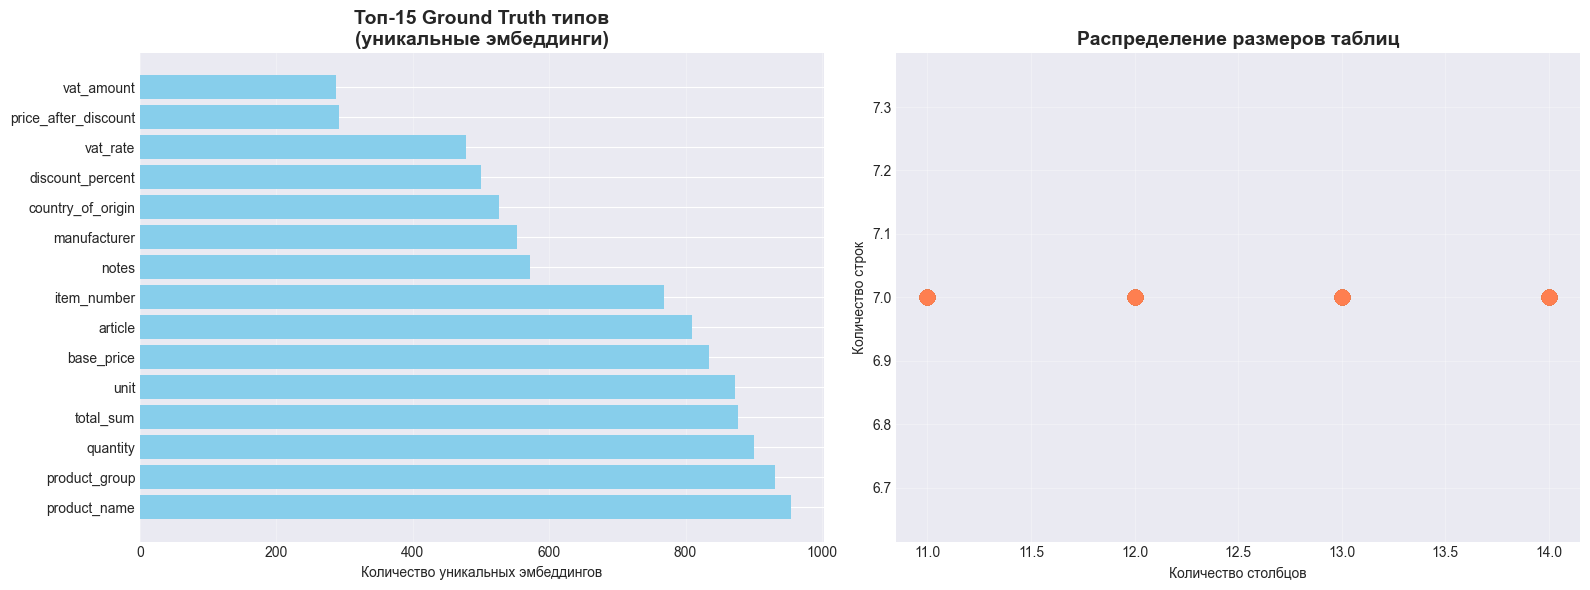

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Распределение Ground Truth типов (уникальные эмбеддинги)
gt_counts = pd.Series(ground_truth_names).value_counts().head(15)
axes[0].barh(range(len(gt_counts)), gt_counts.values, color='skyblue')
axes[0].set_yticks(range(len(gt_counts)))
axes[0].set_yticklabels(gt_counts.index)
axes[0].set_xlabel('Количество уникальных эмбеддингов')
axes[0].set_title('Топ-15 Ground Truth типов\n(уникальные эмбеддинги)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# График 2: Распределение размеров таблиц
if isinstance(metadata, list):
    row_counts = [meta.get('num_rows', meta.get('row_count', 0)) for meta in metadata]
    col_counts = [meta.get('num_columns', meta.get('column_count', 0)) for meta in metadata]
else:  # dict
    row_counts = [meta.get('num_rows', meta.get('row_count', 0)) for meta in metadata.values()]
    col_counts = [meta.get('num_columns', meta.get('column_count', 0)) for meta in metadata.values()]

axes[1].scatter(col_counts, row_counts, alpha=0.6, s=100, color='coral')
axes[1].set_xlabel('Количество столбцов')
axes[1].set_ylabel('Количество строк')
axes[1].set_title('Распределение размеров таблиц', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(analysis_dir / '01_distributions.png', dpi=300, bbox_inches='tight')
print(f"✅ Сохранено: {analysis_dir / '01_distributions.png'}")
plt.show()


## 6️⃣ Подготовка эмбеддингов для визуализации

In [122]:
# Извлекаем УНИКАЛЬНЫЕ эмбеддинги (дубликаты уже удалены в ячейке 3)
embeddings = np.array([entry['embedding'] for entry in dataset])
labels = [entry['ground_truth_name'] for entry in dataset]

print(f"📊 УНИКАЛЬНЫЕ ЭМБЕДДИНГИ:")
print(f"   Всего векторов: {embeddings.shape[0]}")
print(f"   Размерность: {embeddings.shape[1]}")

# Создаем объекты EmbSerialV2 для визуализатора
emb_serials = []
emb_labels = []  # Ground Truth метки для раскраски
for i, entry in enumerate(dataset):
    emb_serial = EmbSerialV2(
        name=entry['column_name'],
        content=entry['content_sample'],
        embedding=np.array(entry['embedding']),
        description=entry['llm_description'],
        data_type=entry.get('data_type')
    )
    emb_serials.append(emb_serial)
    emb_labels.append(entry['ground_truth_name'])

print(f"\n✅ Создано {len(emb_serials)} объектов EmbSerialV2 (все уникальные)")
print(f"   Уникальных классов (Ground Truth): {len(set(emb_labels))}")


📊 УНИКАЛЬНЫЕ ЭМБЕДДИНГИ:
   Всего векторов: 10405
   Размерность: 4096

✅ Создано 10405 объектов EmbSerialV2 (все уникальные)
   Уникальных классов (Ground Truth): 16

✅ Создано 10405 объектов EmbSerialV2 (все уникальные)
   Уникальных классов (Ground Truth): 16


## 7️⃣ Визуализация пространства уникальных эмбеддингов (t-SNE)

🔄 Запуск t-SNE для 10405 УНИКАЛЬНЫХ эмбеддингов...
✅ t-SNE завершён
ℹ️  Лейблы отключены (SHOW_LABELS=False)
✅ t-SNE завершён
ℹ️  Лейблы отключены (SHOW_LABELS=False)
✅ Сохранено: C:\Work\TableUnifier\dataset_1000t_qwen3_8b_qwen3-embedding_8b\analysis_results\02_tsne_visualization.png
✅ Сохранено: C:\Work\TableUnifier\dataset_1000t_qwen3_8b_qwen3-embedding_8b\analysis_results\02_tsne_visualization.png


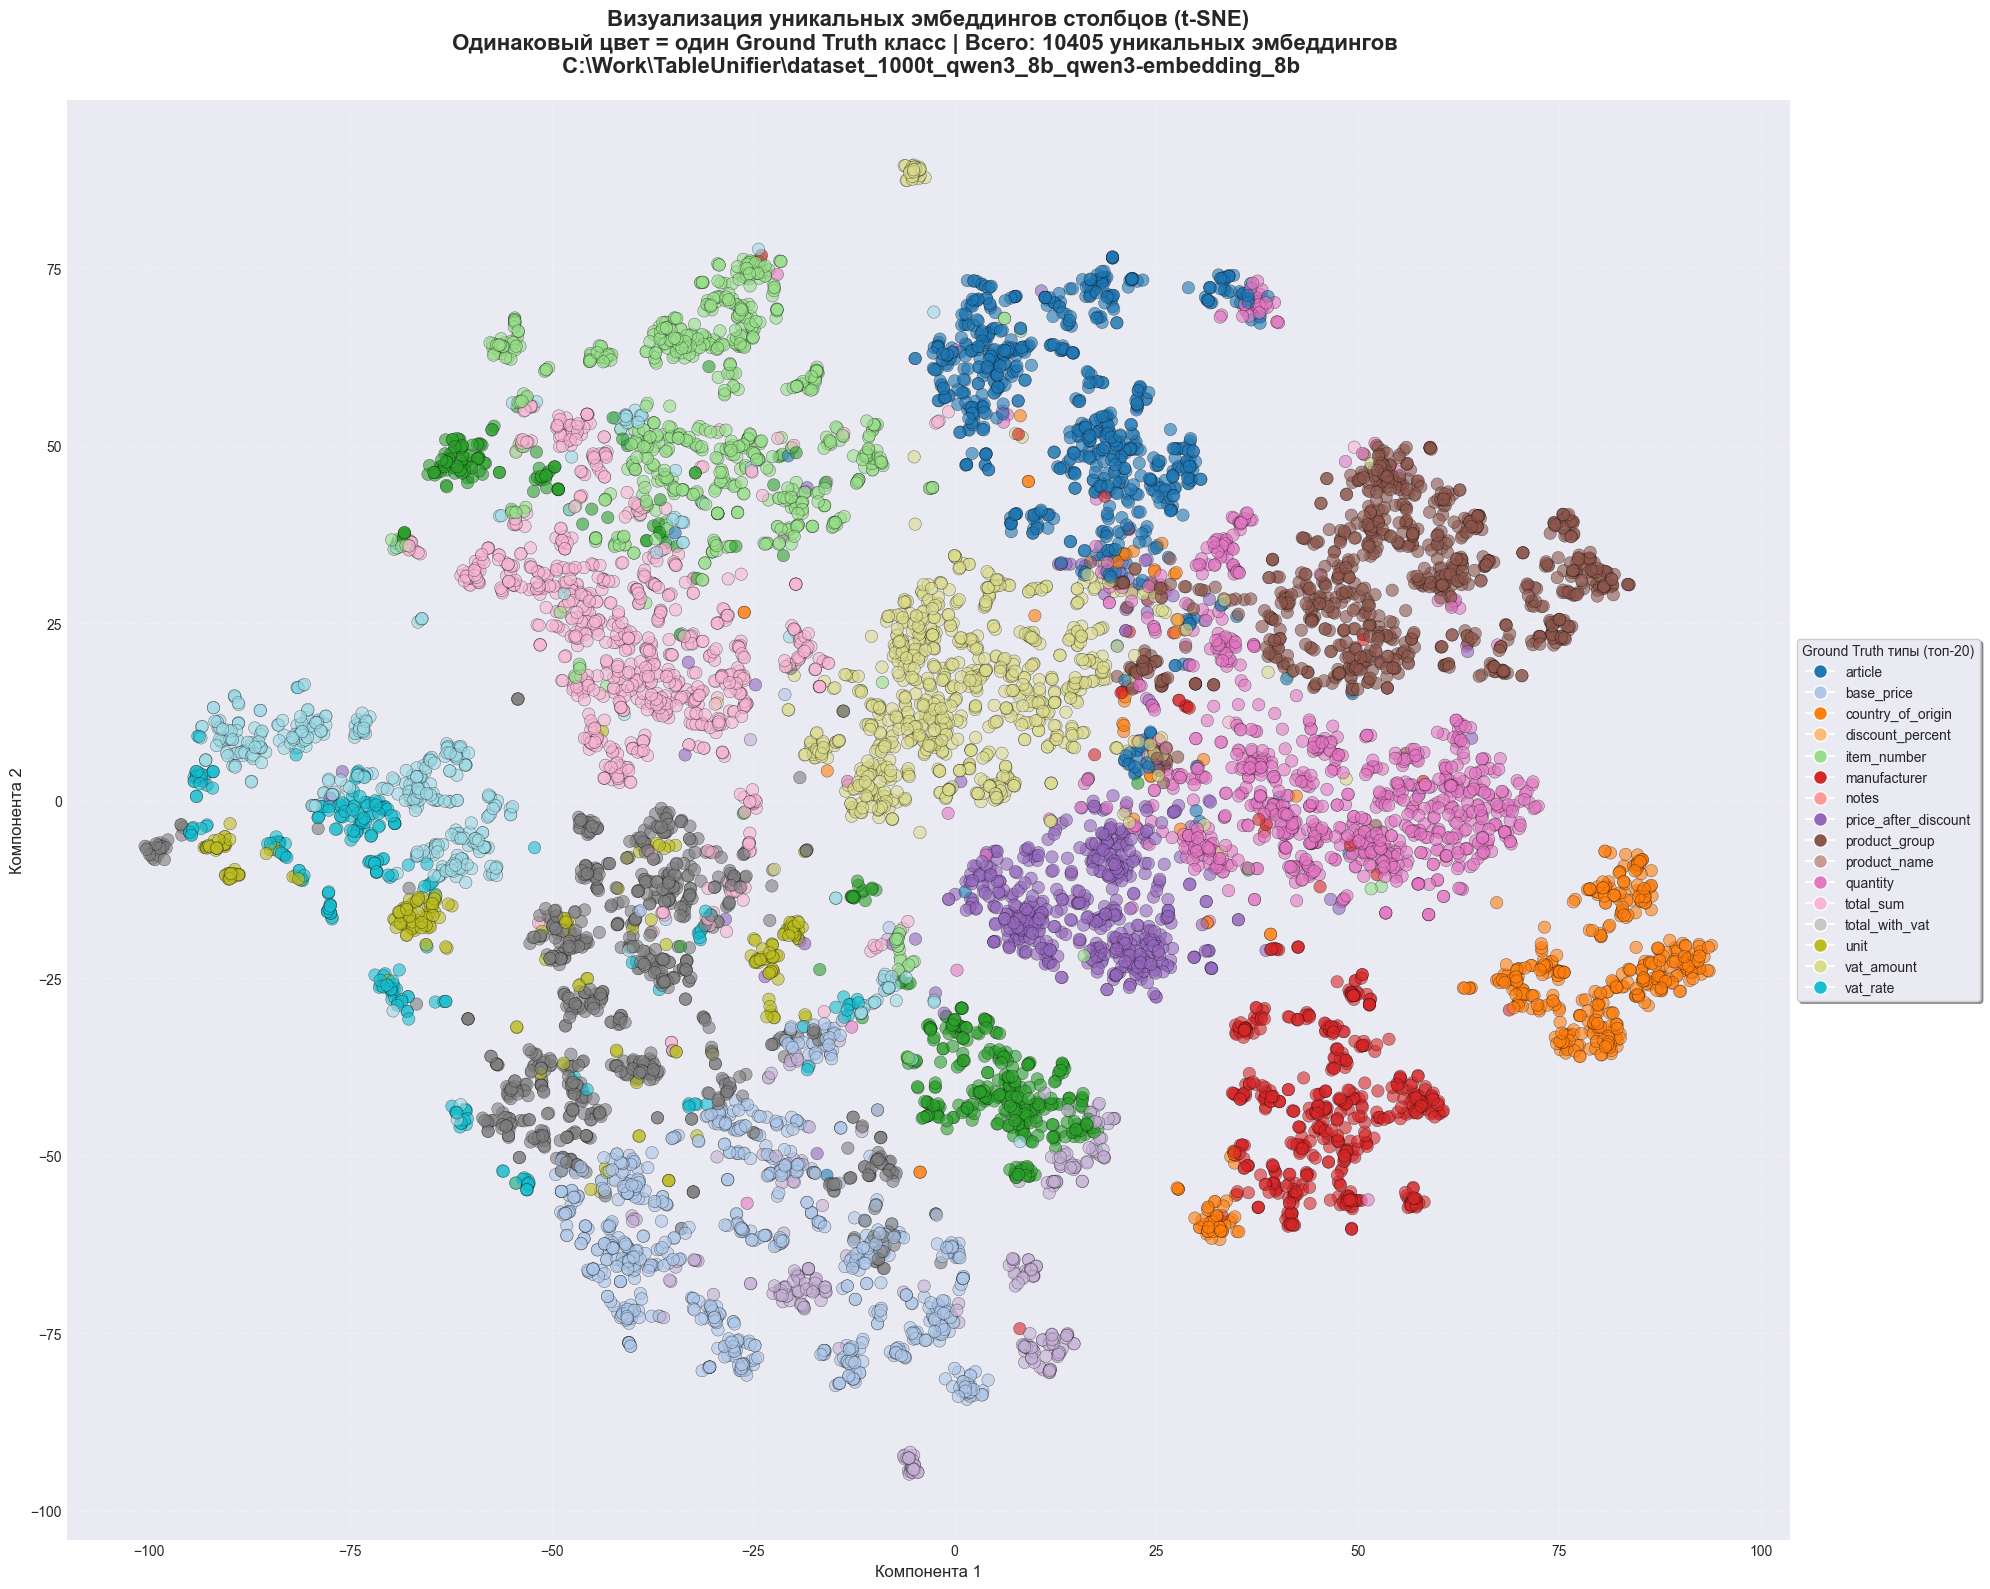


📊 Визуализировано 10405 УНИКАЛЬНЫХ эмбеддингов
   Классов: 16


In [123]:
# Визуализация через t-SNE с раскраской по классам
from sklearn.manifold import TSNE

# ⚙️ НАСТРОЙКА ОТОБРАЖЕНИЯ ЛЕЙБЛОВ
SHOW_LABELS = False  # True - показать названия столбцов, False - скрыть

# Получаем уникальные эмбеддинги (дубликаты уже удалены)
embeddings_viz = np.array([col.embedding for col in emb_serials])

print(f"🔄 Запуск t-SNE для {len(emb_serials)} УНИКАЛЬНЫХ эмбеддингов...")

# t-SNE редукция
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(emb_serials)-1))
coords_2d = tsne.fit_transform(embeddings_viz)

print(f"✅ t-SNE завершён")

# Создаем маппинг: ground_truth_name -> цвет (числовой индекс)
unique_labels = sorted(set(emb_labels))
label_to_color = {label: i for i, label in enumerate(unique_labels)}
colors = [label_to_color[label] for label in emb_labels]

# Визуализация
plt.figure(figsize=(20, 16))
scatter = plt.scatter(coords_2d[:, 0], coords_2d[:, 1], 
                     s=80, alpha=0.6, c=colors, cmap='tab20', edgecolors='black', linewidth=0.3)

# Аннотации для каждой точки (опционально)
if SHOW_LABELS:
    print(f"🏷️  Добавление {len(emb_serials)} лейблов...")
    for i, (col, label) in enumerate(zip(emb_serials, emb_labels)):
        plt.annotate(f"{col.name[:20]}", 
                    (coords_2d[i, 0], coords_2d[i, 1]), 
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=6, alpha=0.7,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.5, edgecolor='none'))
else:
    print(f"ℹ️  Лейблы отключены (SHOW_LABELS=False)")

plt.title(f'Визуализация уникальных эмбеддингов столбцов (t-SNE)\nОдинаковый цвет = один Ground Truth класс | Всего: {len(emb_serials)} уникальных эмбеддингов \n {DATASET_DIR}', 
         fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Компонента 1', fontsize=12)
plt.ylabel('Компонента 2', fontsize=12)
plt.grid(alpha=0.3, linestyle='--')

# Легенда с классами
handles = [plt.Line2D([0], [0], marker='o', color='w', 
                     markerfacecolor=plt.cm.tab20(label_to_color[label]/len(unique_labels)), 
                     markersize=10, label=label)
          for label in unique_labels[:20]]  # Первые 20 для читаемости
if handles:
    plt.legend(handles=handles, title='Ground Truth типы (топ-20)', 
              loc='center left', bbox_to_anchor=(1, 0.5), 
              frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.savefig(analysis_dir / '02_tsne_visualization.png', dpi=300, bbox_inches='tight')
print(f"✅ Сохранено: {analysis_dir / '02_tsne_visualization.png'}")
plt.show()

print(f"\n📊 Визуализировано {len(emb_serials)} УНИКАЛЬНЫХ эмбеддингов")
print(f"   Классов: {len(unique_labels)}")


## 8️⃣ Матрица схожести столбцов

🔍 МАТРИЦА СХОЖЕСТИ МЕЖДУ ТИПАМИ СТОЛБЦОВ

📊 Выбрано 15 наиболее частых типов
   По 20 примеров от каждого типа
   Типы: product_name, product_group, quantity, total_sum, unit...

⏳ Вычисление матрицы сходств 15x15...
✅ Матрица вычислена
✅ Матрица вычислена

✅ Сохранено: C:\Work\TableUnifier\dataset_1000t_qwen3_8b_qwen3-embedding_8b\analysis_results\04_similarity_matrix.png

✅ Сохранено: C:\Work\TableUnifier\dataset_1000t_qwen3_8b_qwen3-embedding_8b\analysis_results\04_similarity_matrix.png


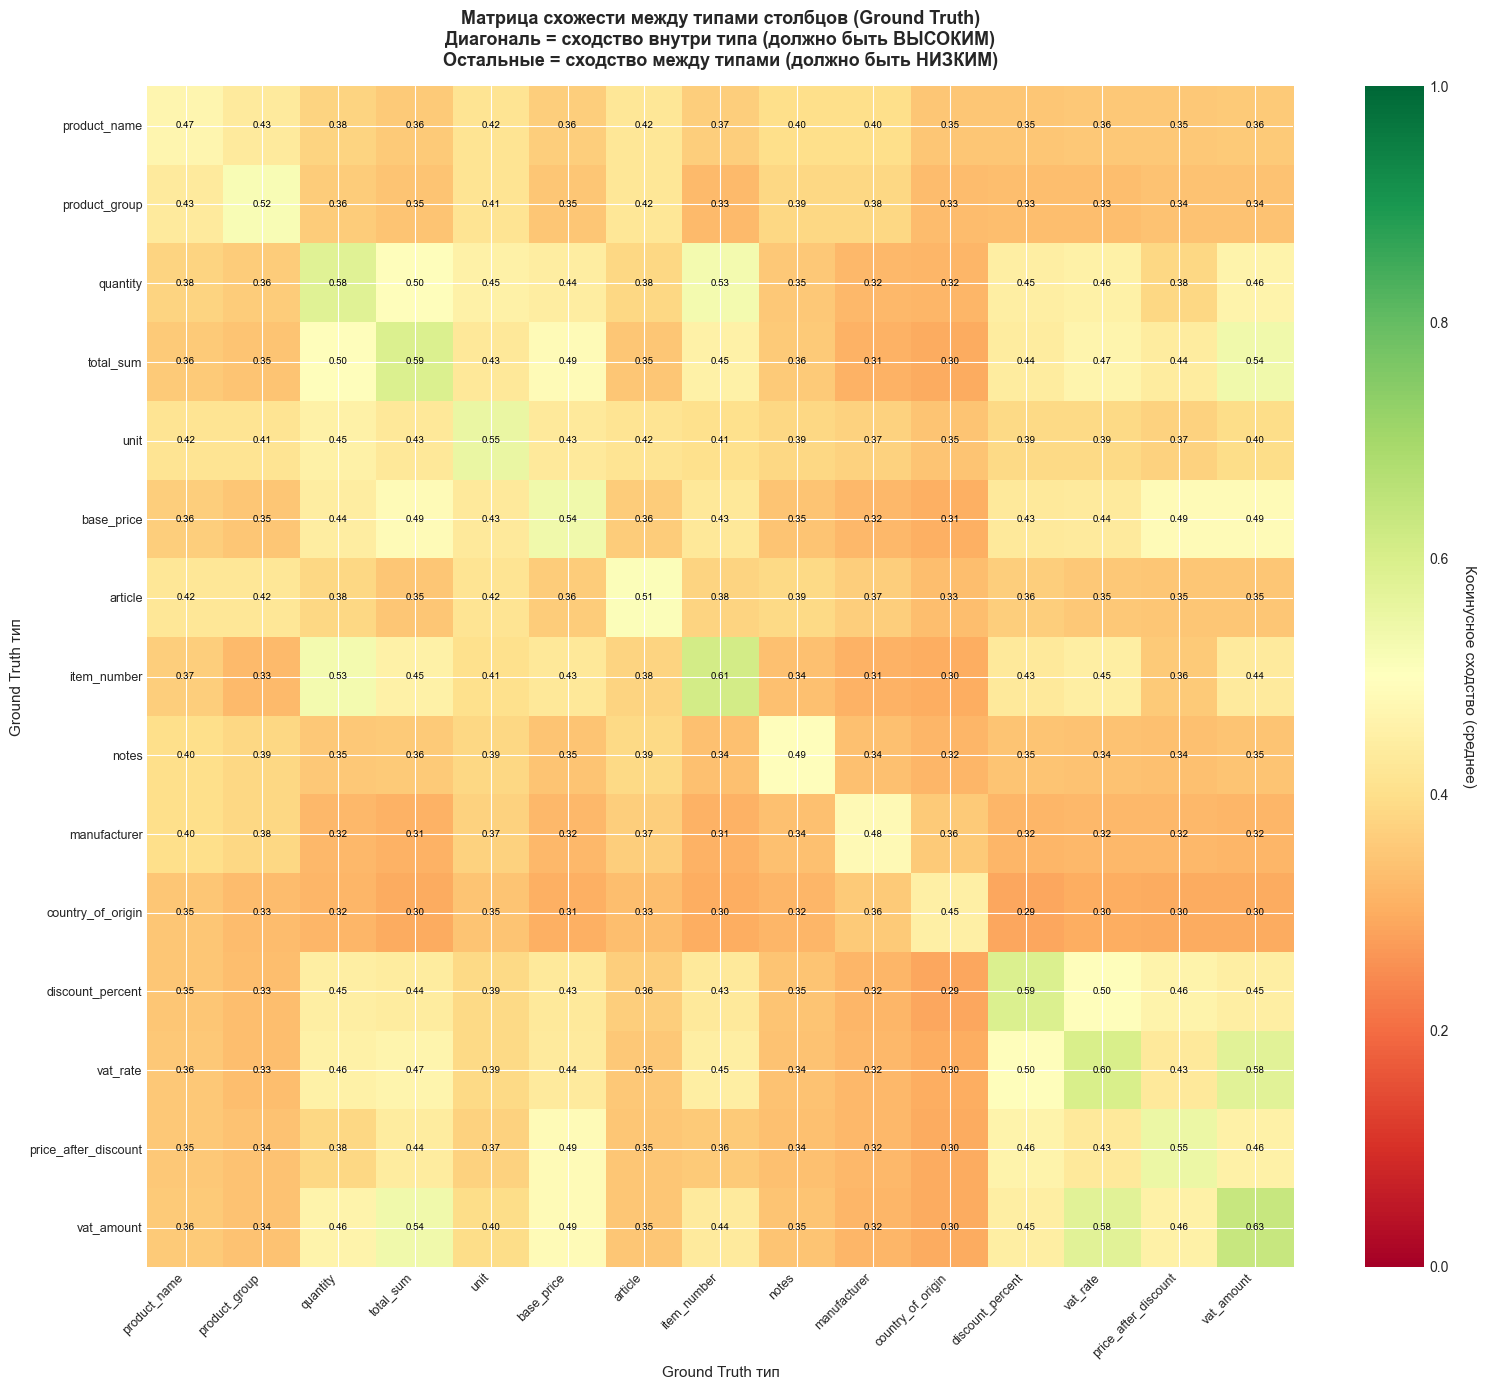


📊 СТАТИСТИКА МАТРИЦЫ:
   Диагональ (внутри типа):
      Среднее:  0.545
      Мин:      0.450
      Макс:     0.634
   Недиагональ (между типами):
      Среднее:  0.384
      Мин:      0.292
      Макс:     0.576

💡 Разделимость: диагональ - недиагональ = 0.160
   (Чем выше, тем лучше модель различает типы)


In [124]:
# Матрица схожести между типами столбцов (Ground Truth)
# По осям - уникальные GT типы, в ячейках - среднее косинусное сходство

from sklearn.metrics.pairwise import cosine_similarity

print("🔍 МАТРИЦА СХОЖЕСТИ МЕЖДУ ТИПАМИ СТОЛБЦОВ")
print("="*80)

# Берём топ-N наиболее частых типов для матрицы
gt_counter_temp = Counter([entry['ground_truth_name'] for entry in dataset])
N_TYPES = 15  # Количество типов для матрицы
SAMPLES_PER_TYPE = 20  # Количество примеров на тип (для усреднения)

top_gt_types = [gt for gt, count in gt_counter_temp.most_common(N_TYPES)]

print(f"\n📊 Выбрано {len(top_gt_types)} наиболее частых типов")
print(f"   По {SAMPLES_PER_TYPE} примеров от каждого типа")
print(f"   Типы: {', '.join(top_gt_types[:5])}...")

# Собираем сбалансированную выборку
gt_embeddings = {}  # gt_type -> список эмбеддингов
for gt_type in top_gt_types:
    type_entries = [e for e in dataset if e['ground_truth_name'] == gt_type][:SAMPLES_PER_TYPE]
    gt_embeddings[gt_type] = [np.array(e['embedding']) for e in type_entries]

# Вычисляем матрицу средних сходств
n_types = len(top_gt_types)
similarity_matrix = np.zeros((n_types, n_types))

print(f"\n⏳ Вычисление матрицы сходств {n_types}x{n_types}...")

for i, gt_type1 in enumerate(top_gt_types):
    for j, gt_type2 in enumerate(top_gt_types):
        if i == j:
            # Диагональ - сходство внутри типа (должно быть высоким)
            embs = gt_embeddings[gt_type1]
            if len(embs) > 1:
                # Сходство между всеми парами внутри типа
                sims = cosine_similarity(embs)
                # Среднее без диагонали
                mask = ~np.eye(len(embs), dtype=bool)
                similarity_matrix[i, j] = sims[mask].mean()
            else:
                similarity_matrix[i, j] = 1.0
        else:
            # Недиагональные элементы - сходство между разными типами
            embs1 = gt_embeddings[gt_type1]
            embs2 = gt_embeddings[gt_type2]
            # Среднее косинусное сходство между всеми парами
            sims = cosine_similarity(embs1, embs2)
            similarity_matrix[i, j] = sims.mean()

print(f"✅ Матрица вычислена")

# Визуализация
fig, ax = plt.subplots(figsize=(16, 14))

# Тепловая карта
im = ax.imshow(similarity_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Настройка осей
ax.set_xticks(range(n_types))
ax.set_yticks(range(n_types))
ax.set_xticklabels([gt[:25] for gt in top_gt_types], rotation=45, ha='right', fontsize=9)
ax.set_yticklabels([gt[:25] for gt in top_gt_types], fontsize=9)

# Добавляем значения в ячейки
for i in range(n_types):
    for j in range(n_types):
        text = ax.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=7)

# Цветовая шкала
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Косинусное сходство (среднее)', rotation=270, labelpad=20, fontsize=11)

# Заголовок
ax.set_title('Матрица схожести между типами столбцов (Ground Truth)\n'
            'Диагональ = сходство внутри типа (должно быть ВЫСОКИМ)\n'
            'Остальные = сходство между типами (должно быть НИЗКИМ)',
            fontsize=13, fontweight='bold', pad=15)

ax.set_xlabel('Ground Truth тип', fontsize=11)
ax.set_ylabel('Ground Truth тип', fontsize=11)

plt.tight_layout()
plt.savefig(analysis_dir / '04_similarity_matrix.png', dpi=300, bbox_inches='tight')
print(f"\n✅ Сохранено: {analysis_dir / '04_similarity_matrix.png'}")
plt.show()

# Статистика
diag = np.diag(similarity_matrix)
off_diag = similarity_matrix[~np.eye(n_types, dtype=bool)]

print(f"\n📊 СТАТИСТИКА МАТРИЦЫ:")
print(f"   Диагональ (внутри типа):")
print(f"      Среднее:  {diag.mean():.3f}")
print(f"      Мин:      {diag.min():.3f}")
print(f"      Макс:     {diag.max():.3f}")
print(f"   Недиагональ (между типами):")
print(f"      Среднее:  {off_diag.mean():.3f}")
print(f"      Мин:      {off_diag.min():.3f}")
print(f"      Макс:     {off_diag.max():.3f}")
print(f"\n💡 Разделимость: диагональ - недиагональ = {diag.mean() - off_diag.mean():.3f}")
print(f"   (Чем выше, тем лучше модель различает типы)")
print("="*80)


## 9️⃣ Итоговый отчет и сохранение

In [125]:
# Финальная оценка качества
total_unique_descriptions = len(set(llm_descriptions))  # Уникальность по описаниям!
total_unique_column_names = len(set([entry['column_name'] for entry in dataset]))

# Сохраняем вывод в буфер
import io
import sys
from datetime import datetime

output_buffer = io.StringIO()

# Функция для печати и сохранения
def print_and_save(text, file=None):
    print(text)
    output_buffer.write(text + '\n')

print_and_save("🎯 ИТОГОВЫЙ ОТЧЕТ КАЧЕСТВА ДАТАСЕТА")
print_and_save("="*80)
print_and_save(f"\n✅ РАЗМЕР ДАТАСЕТА:")
print_and_save(f"   Таблиц: {len(metadata)}")
print_and_save(f"   Уникальных записей: {len(dataset)}")
if 'dataset_original' in locals() and len(dataset) != len(dataset_original):
    print_and_save(f"   Было изначально: {len(dataset_original)}")
    print_and_save(f"   Удалено дубликатов: {len(dataset_original) - len(dataset)} ({(len(dataset_original) - len(dataset))/len(dataset_original)*100:.1f}%)")

print_and_save(f"\n🎨 РАЗНООБРАЗИЕ:")
print_and_save(f"   Уникальных типов столбцов (Ground Truth): {len(gt_counter)}")
print_and_save(f"   Уникальных LLM описаний: {total_unique_descriptions}")
print_and_save(f"   Уникальных названий столбцов: {total_unique_column_names}")
print_and_save(f"   Описаний на запись: {total_unique_descriptions/len(dataset):.2f}")

print_and_save(f"\n✅ ВЕРДИКТ:")
if 'dataset_original' in locals() and len(dataset) == len(dataset_original):
    print_and_save("   🌟 ОТЛИЧНОЕ качество! Все описания изначально уникальны!")
elif 'dataset_original' in locals():
    removed_percent = (len(dataset_original) - len(dataset)) / len(dataset_original) * 100
    if removed_percent < 5:
        print_and_save(f"   ✅ ХОРОШЕЕ качество. Удалено мало дубликатов ({removed_percent:.1f}%)")
    elif removed_percent < 15:
        print_and_save(f"   ⚠️  СРЕДНЕЕ качество. Удалено {removed_percent:.1f}% дубликатов")
    else:
        print_and_save(f"   ❌ НИЗКОЕ качество. Удалено много дубликатов ({removed_percent:.1f}%)")
else:
    print_and_save("   ✅ Анализ на уникальных описаниях")

print_and_save(f"\n💡 Датасет содержит {len(dataset)} УНИКАЛЬНЫХ записей")
print_and_save(f"   Готов к использованию для обучения!")
print_and_save("\n" + "="*80)

# Сохраняем текстовый отчет
report_text_path = analysis_dir / 'analysis_summary.txt'
with open(report_text_path, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("АНАЛИЗ КАЧЕСТВА ДАТАСЕТА V3\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"📁 Датасет: {dataset_dir}\n")
    f.write(f"📅 Дата анализа: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    f.write(output_buffer.getvalue())

print(f"\n📄 Отчет сохранен: {report_text_path}")


🎯 ИТОГОВЫЙ ОТЧЕТ КАЧЕСТВА ДАТАСЕТА

✅ РАЗМЕР ДАТАСЕТА:
   Таблиц: 1000
   Уникальных записей: 10405
   Было изначально: 11781
   Удалено дубликатов: 1376 (11.7%)

🎨 РАЗНООБРАЗИЕ:
   Уникальных типов столбцов (Ground Truth): 16
   Уникальных LLM описаний: 10405
   Уникальных названий столбцов: 3992
   Описаний на запись: 1.00

✅ ВЕРДИКТ:
   ⚠️  СРЕДНЕЕ качество. Удалено 11.7% дубликатов

💡 Датасет содержит 10405 УНИКАЛЬНЫХ записей
   Готов к использованию для обучения!


📄 Отчет сохранен: C:\Work\TableUnifier\dataset_1000t_qwen3_8b_qwen3-embedding_8b\analysis_results\analysis_summary.txt


In [126]:
# Сохраняем очищенный датасет (без дубликатов)
if 'dataset_original' in locals() and len(dataset) < len(dataset_original):
    cleaned_dataset_path = dataset_dir / "dataset_v3_cleaned.json"
    
    with open(cleaned_dataset_path, 'w', encoding='utf-8') as f:
        json.dump(dataset, f, ensure_ascii=False, indent=2)
    
    print(f"\n✅ Очищенный датасет сохранён: {cleaned_dataset_path}")
    print(f"   Исходно:  {len(dataset_original)} записей")
    print(f"   Очищено:  {len(dataset)} записей")
    print(f"   Удалено:  {len(dataset_original) - len(dataset)} дубликатов ({(len(dataset_original) - len(dataset))/len(dataset_original)*100:.1f}%)")
else:
    print("\nℹ️  Дубликаты не найдены, очищенный датасет не создан")


✅ Очищенный датасет сохранён: C:\Work\TableUnifier\dataset_1000t_qwen3_8b_qwen3-embedding_8b\dataset_v3_cleaned.json
   Исходно:  11781 записей
   Очищено:  10405 записей
   Удалено:  1376 дубликатов (11.7%)
